In [ ]:
# use the simple moving average crossover strategy and python to get buy and sell signals. 

In [76]:
#importing the libraries 

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
plt.style.use('fivethirtyeight')

In [77]:
#load the data
import pandas as pd

df = pd.read_csv('AAPL.csv')
df.head()

,Date,Open,High,Low,Close,Volume
0,12/2025,278.01,288.62,266.95,271.86,"923,439,051"
1,11/2025,270.42,280.38,265.32,278.85,"877,574,804"
2,10/2025,255.04,277.32,244.00,270.37,"1,097,142,356"
3,09/2025,229.25,257.60,225.95,254.63,"1,265,536,448"
4,08/2025,210.87,235.12,201.50,232.14,"1,218,125,297"


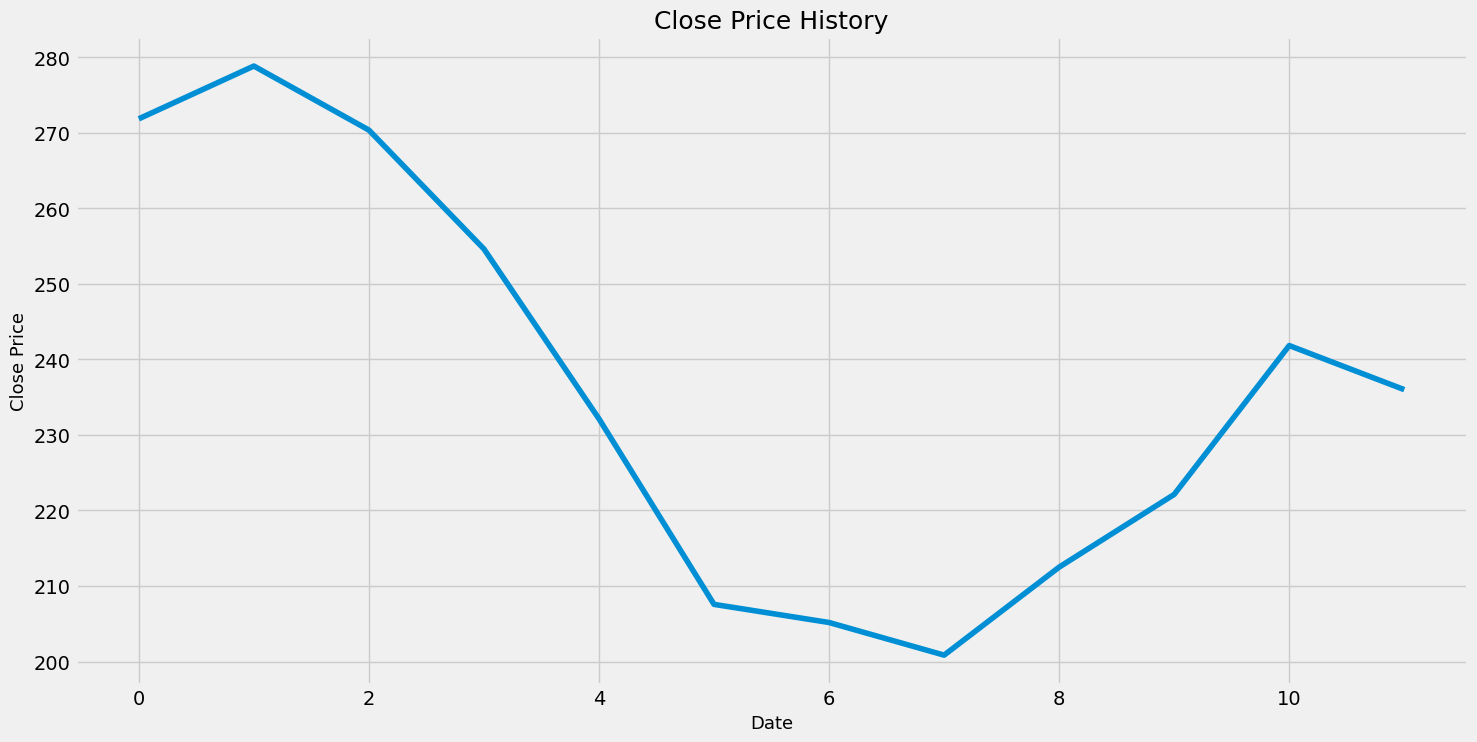

In [78]:
# visually show the close price 
plt.figure(figsize=(16, 8))
plt.title('Close Price History' , fontsize=18)
plt.plot(df['Close'], label='Close Price')
plt.xlabel('Date', fontsize=13)
plt.ylabel('Close Price', fontsize=13)
plt.show()     # make Date the index


In [79]:
# create a function to calculate the simple moving average or SMA. 
def SMA(data, period=30, column='Close'):
    return data[column].rolling(window=period).mean()


In [80]:
# create two new columns 'SMA3' and 'SMA6' to the dataframe
df['SMA3'] = SMA(df, period=3, column='Close')
df['SMA6'] = SMA(df, period=6, column='Close')    

In [81]:
#get the buy and sell signals
df['Signal'] = np.where(df['SMA3'] > df['SMA6'], 1, 0)
df['Position'] = df['Signal'].diff()

df['Buy'] = np.where(df['Position'] == 1, df['Close'], np.nan)
df['Sell'] = np.where(df['Position'] == -1, df['Close'], np.nan)

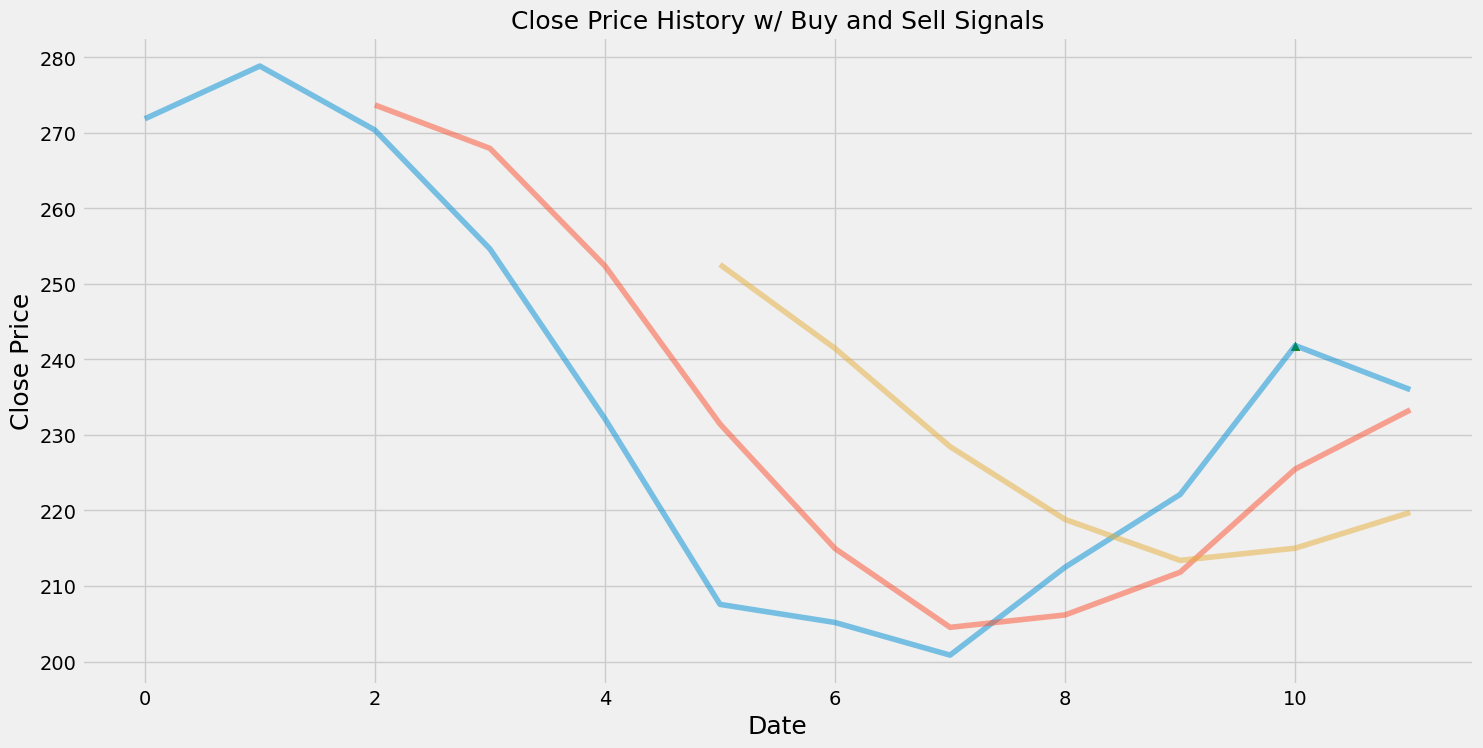

In [82]:
#visually show the close price with the SMAs and the buy and sell signals
plt.figure(figsize=(16, 8))
plt.title('Close Price History w/ Buy and Sell Signals', fontsize=18)
plt.plot(df['Close'], label='Close Price', alpha=0.5)

plt.plot(df['SMA3'], label='SMA3', alpha=0.5)
plt.plot(df['SMA6'], label='SMA6', alpha=0.5)

plt.scatter(df.index, df['Buy'], alpha=1, label= 'buy signal', marker='^', color='green')
plt.scatter(df.index, df['Sell'], alpha=1, label= 'sell signal', marker='v', color='red')

plt.xlabel('Date', fontsize=18)
plt.ylabel('Close Price', fontsize=18)
plt.show()